<a href="https://colab.research.google.com/github/Pathikrit003/ML/blob/main/assignment2_wholesale_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [32]:
df = pd.read_csv("Wholesale customers data.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [33]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized features shape:", X_scaled.shape)
X_scaled

Standardized features shape: (440, 6)


array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       ...,
       [ 0.20032554,  1.31467078,  2.34838631, -0.54337975,  2.51121768,
         0.12145607],
       [-0.13538389, -0.51753572, -0.60251388, -0.41944059, -0.56977032,
         0.21304614],
       [-0.72930698, -0.5559243 , -0.57322717, -0.62009417, -0.50488752,
        -0.52286938]])

In [34]:
Z_single = linkage(X_scaled, method='single')

Z_complete = linkage(X_scaled, method='complete')

Z_average = linkage(X_scaled, method='average')

print("Hierarchical trees generated successfully!")

Hierarchical trees generated successfully!


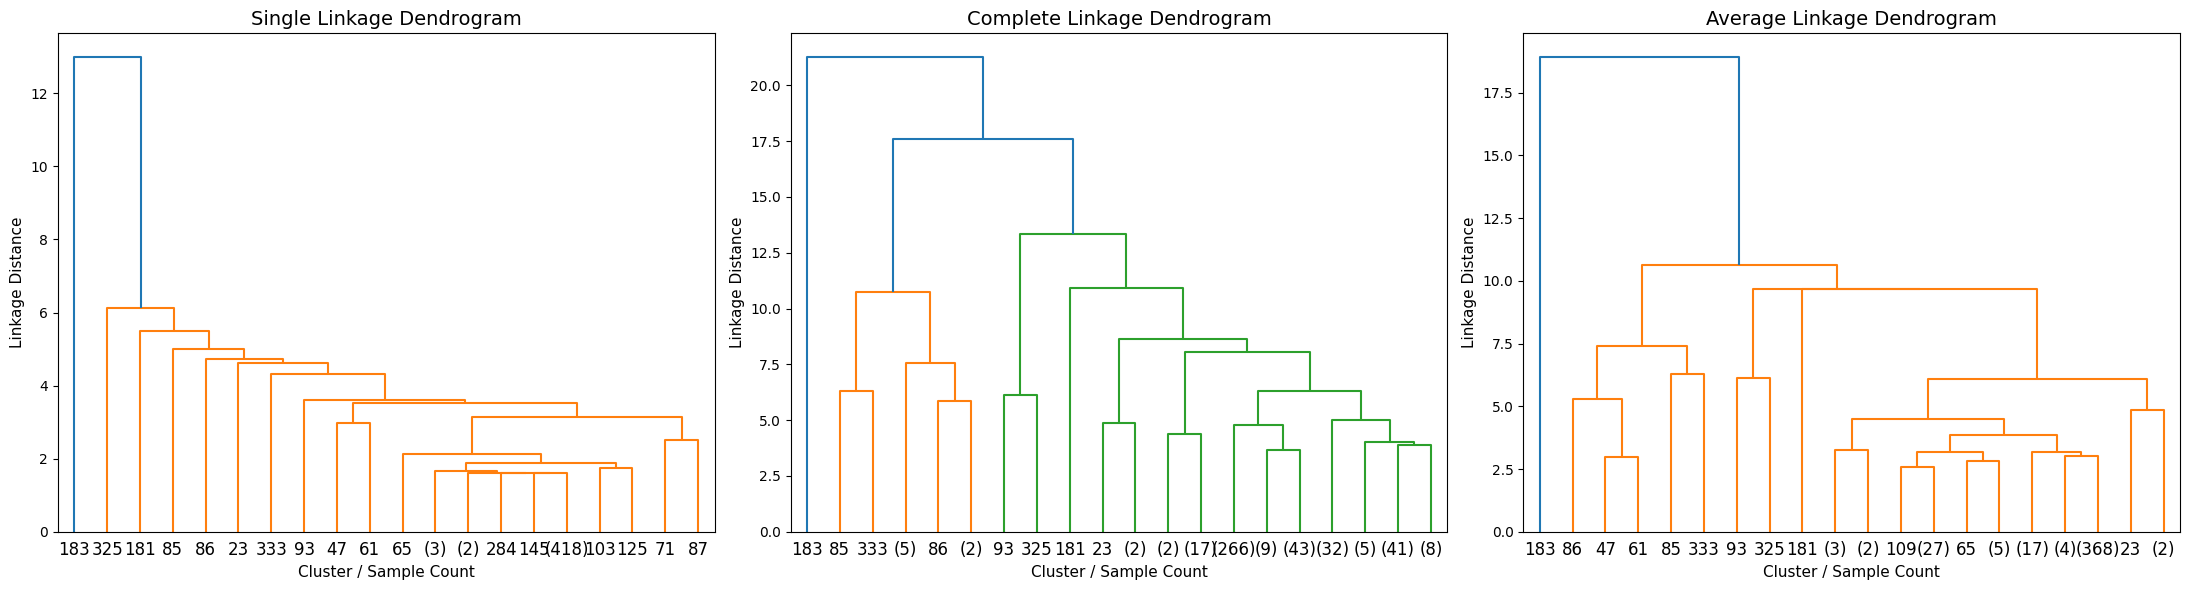

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

dendrogram(Z_single, ax=axes[0], truncate_mode='lastp', p=20)
axes[0].set_title("Single Linkage Dendrogram", fontsize=14)
axes[0].set_xlabel("Cluster / Sample Count", fontsize=11)
axes[0].set_ylabel("Linkage Distance", fontsize=11)


dendrogram(Z_complete, ax=axes[1], truncate_mode='lastp', p=20)
axes[1].set_title("Complete Linkage Dendrogram", fontsize=14)
axes[1].set_xlabel("Cluster / Sample Count", fontsize=11)
axes[1].set_ylabel("Linkage Distance", fontsize=11)


dendrogram(Z_average, ax=axes[2], truncate_mode='lastp', p=20)
axes[2].set_title("Average Linkage Dendrogram", fontsize=14)
axes[2].set_xlabel("Cluster / Sample Count", fontsize=11)
axes[2].set_ylabel("Linkage Distance", fontsize=11)

plt.tight_layout()
plt.show()

In [36]:
linkage_matrices = {
    "Single Linkage": Z_single,
    "Complete Linkage": Z_complete,
    "Average Linkage": Z_average
}

for name, Z in linkage_matrices.items():
    print(f"\n--- {name} (Final 5 Merges) ---")
    merge_df = pd.DataFrame(
        Z[-5:],
        columns=['Cluster A', 'Cluster B', 'Distance (Height)', 'Cluster Size'],
        index=[f"Merge {i}" for i in range(len(Z)-4, len(Z)+1)]
    )
    print(merge_df)


--- Single Linkage (Final 5 Merges) ---
           Cluster A  Cluster B  Distance (Height)  Cluster Size
Merge 435       86.0      873.0           4.735888         436.0
Merge 436       85.0      874.0           4.992715         437.0
Merge 437      181.0      875.0           5.489247         438.0
Merge 438      325.0      876.0           6.113617         439.0
Merge 439      183.0      877.0          12.992277         440.0

--- Complete Linkage (Final 5 Merges) ---
           Cluster A  Cluster B  Distance (Height)  Cluster Size
Merge 435      869.0      871.0          10.760837          10.0
Merge 436      181.0      873.0          10.941772         427.0
Merge 437      868.0      875.0          13.326882         429.0
Merge 438      874.0      876.0          17.588526         439.0
Merge 439      183.0      877.0          21.268447         440.0

--- Average Linkage (Final 5 Merges) ---
           Cluster A  Cluster B  Distance (Height)  Cluster Size
Merge 435      870.0      873

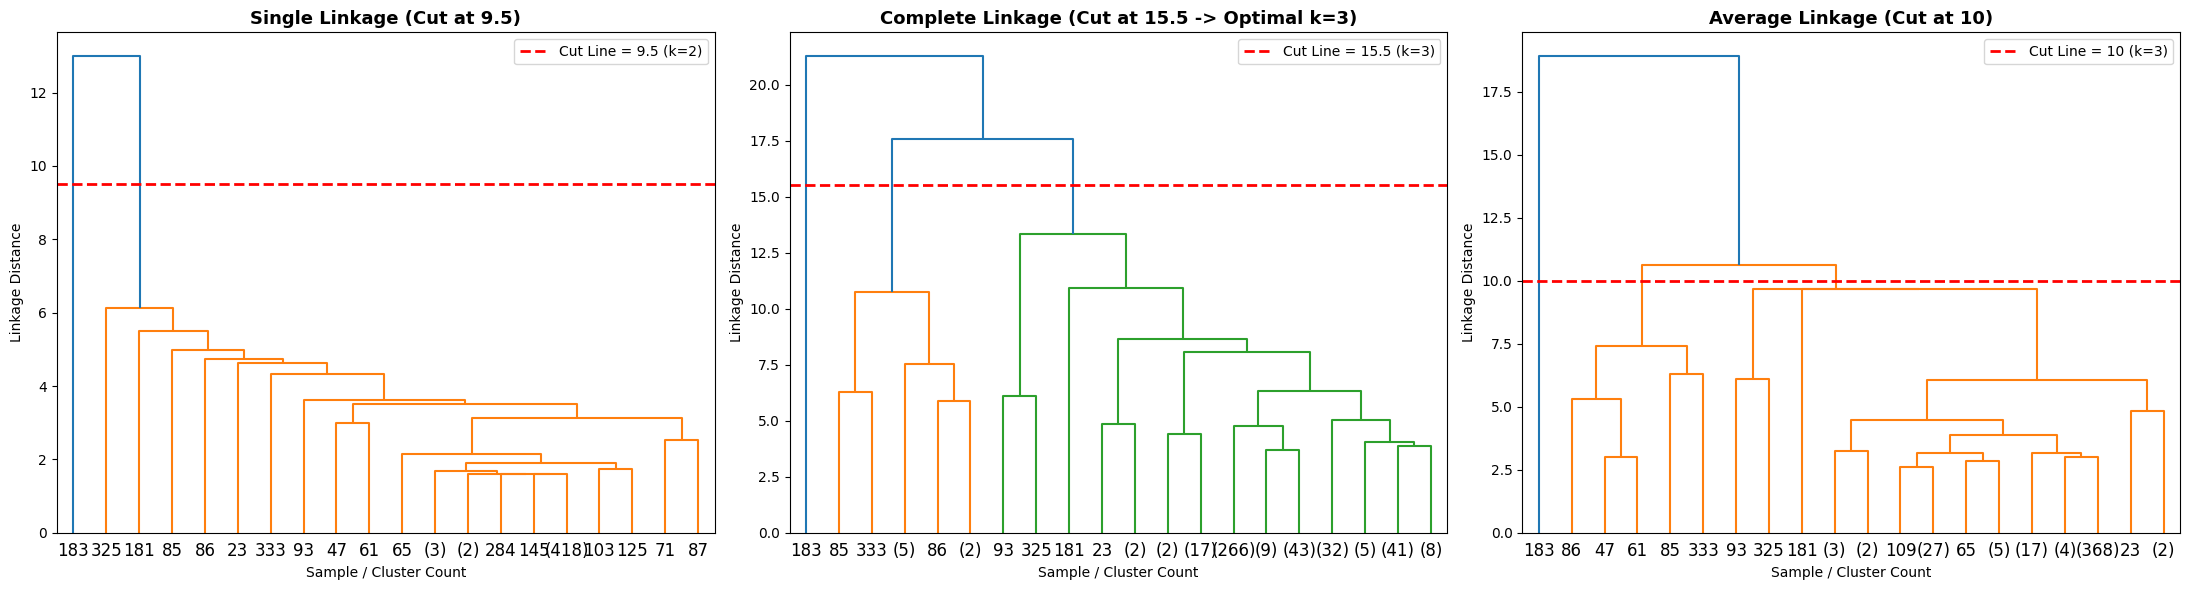

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

dendrogram(Z_single, ax=axes[0], truncate_mode='lastp', p=20)
axes[0].axhline(y=9.5, color='r', linestyle='--', linewidth=2, label='Cut Line = 9.5 (k=2)')
axes[0].set_title("Single Linkage (Cut at 9.5)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sample / Cluster Count")
axes[0].set_ylabel("Linkage Distance")
axes[0].legend(loc='upper right')

dendrogram(Z_complete, ax=axes[1], truncate_mode='lastp', p=20)
axes[1].axhline(y=15.5, color='r', linestyle='--', linewidth=2, label='Cut Line = 15.5 (k=3)')
axes[1].set_title("Complete Linkage (Cut at 15.5 -> Optimal k=3)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Sample / Cluster Count")
axes[1].set_ylabel("Linkage Distance")
axes[1].legend(loc='upper right')

dendrogram(Z_average, ax=axes[2], truncate_mode='lastp', p=20)
axes[2].axhline(y=10, color='r', linestyle='--', linewidth=2, label='Cut Line = 10 (k=3)')
axes[2].set_title("Average Linkage (Cut at 10)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Sample / Cluster Count")
axes[2].set_ylabel("Linkage Distance")
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [38]:
k_values = [2, 3, 4, 5]
results = {'k': k_values, 'Single': [], 'Complete': [], 'Average': []}

linkage_dict = {
    'Single': Z_single,
    'Complete': Z_complete,
    'Average': Z_average
}

for method_name, Z in linkage_dict.items():
    for k in k_values:

        cluster_labels = fcluster(Z, t=k, criterion='maxclust')

        score = silhouette_score(X_scaled, cluster_labels)
        results[method_name].append(round(score, 4))

score_df = pd.DataFrame(results)
print("\nSilhouette Scores across Methods:")
display(score_df)



Silhouette Scores across Methods:


,k,Single,Complete,Average
0,2,0.8638,0.8638,0.8638
1,3,0.7966,0.7115,0.7676
2,4,0.7373,0.7119,0.7447
3,5,0.7345,0.7085,0.7368
